# Taller 05: Descubriendo Patrones Musicales con Spotify

## 1. Descripción del Caso
Imagina que trabajas como Data Scientist en una plataforma de streaming musical emergente. El equipo de producto quiere mejorar el sistema de recomendación, pero no tienen etiquetas claras para ciertos tipos de canciones.

Te entregan este conjunto de datos sobre 999 canciones y sus caracteristicas https://www.kaggle.com/datasets/glowstudygram/spotify-songs-and-artists-dataset

El objetivo de la actividad es usar algoritmos de agrupamiento (Clustering) para agrupar las canciones más populares del 2023 basándote únicamente en sus características de audio, ignorando el género o el artista. Luego, deberás interpretar qué representa cada grupo.

## 2. Objetivos de Aprendizaje
* Limpieza de datos.
* Estandarización de variables.
* Reducción de dimensionalidad (PCA).
* Clustering (K-Means o DBScan).
* Interpretación de resultados.

### Bloque 1: Configuración y Carga de Datos
Importa las librerías necesarias y carga el dataset.

In [ ]:
# Importación de Librerías y archivo

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


Base = pd.read_csv(r'C:\Users\Usuario\Downloads\spotifydataset.csv')

### Bloque 2: Limpieza y Preparación
Se debe trabajar solamente con las columnas que describen como es la canción en terminos auditivos:

- track_popularity
- danceability
- energy
- key
- loudness
- mode
- speechiness
- acousticness
- instrumentalness
- liveness
- valence
- tempo

No se deben usar columnas como el artista o genero para evitar sesgos en la agrupación

In [3]:
## Vizualizar la info
Base.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         1000 non-null   int64  
 1   artist_name        1000 non-null   str    
 2   genres             837 non-null    str    
 3   followers          1000 non-null   int64  
 4   artist_popularity  1000 non-null   int64  
 5   artist_url         1000 non-null   str    
 6   track_name         1000 non-null   str    
 7   album_name         1000 non-null   str    
 8   release_date       1000 non-null   str    
 9   duration_ms        1000 non-null   int64  
 10  explicit           1000 non-null   bool   
 11  track_popularity   1000 non-null   int64  
 12  danceability       1000 non-null   float64
 13  energy             1000 non-null   float64
 14  key                1000 non-null   int64  
 15  loudness           1000 non-null   float64
 16  mode               1000 non-null   i

In [4]:
## Eliminar posibles duplicados
Base = Base.drop_duplicates()
print("Duplicados borrados")

Duplicados borrados


In [5]:
### seleccionar filas necesarias 
cancion = [
    "track_popularity", "danceability",
    "energy", "key", "loudness", "mode", "speechiness", "acousticness", "instrumentalness", "liveness", "valence", "tempo"
]

In [ ]:
## Crear una copia con la que vamos a trabajar unicamente las filas que seleccionamos
canciones_limpio = Base[cancion].copy()

In [7]:
canciones_limpio

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,89,0.645,0.646,5,-8.334,1,0.0427,0.0615,0.000030,0.0740,0.295,115.842
1,85,0.795,0.630,7,-5.854,0,0.0434,0.1570,0.000000,0.0732,0.447,97.998
2,83,0.506,0.362,10,-9.480,1,0.0416,0.6700,0.000000,0.1760,0.385,84.726
3,80,0.650,0.825,0,-4.645,1,0.0325,0.0215,0.000024,0.0936,0.593,118.091
4,79,0.787,0.775,1,-6.614,1,0.0548,0.1900,0.000065,0.1130,0.787,118.998
...,...,...,...,...,...,...,...,...,...,...,...,...
995,69,0.751,0.708,0,-5.653,1,0.0545,0.0482,0.000018,0.1070,0.509,108.970
996,64,0.792,0.701,6,-7.198,0,0.2830,0.1050,0.000000,0.7610,0.251,103.890
997,60,0.746,0.978,9,-5.324,1,0.0978,0.0555,0.000041,0.0260,0.653,153.809
998,59,0.749,0.856,2,-5.833,1,0.2350,0.1070,0.000000,0.7450,0.402,103.773


In [13]:
# Convertir los valores que puedan estar en otro formato a numérico 
for song in canciones_limpio:
    canciones_limpio[song] = pd.to_numeric(canciones_limpio[song], errors='coerce')

## colocar los espacios que no tengan valores con Nan y sacar la mediana para que no nos afecten esos valores nulos 
canciones_limpio = canciones_limpio.fillna(canciones_limpio.median())

escala = StandardScaler()
X_escala = escala.fit_transform(canciones_limpio)

arc_escalado = pd.DataFrame(X_escala, columns=canciones_limpio.columns)

print("Matriz de características:")
print(arc_escalado.head())

Matriz de características:
   track_popularity  danceability    energy       key  loudness      mode  \
0          1.238679      0.200823 -0.070192 -0.067277 -0.262122  0.794557   
1          1.071126      1.098154 -0.147313  0.486445  0.291770 -1.258562   
2          0.987349     -0.630704 -1.439104  1.317029 -0.518074  0.794557   
3          0.861684      0.230734  0.792609 -1.451583  0.561793  0.794557   
4          0.819796      1.050296  0.551603 -1.174722  0.122029  0.794557   

   speechiness  acousticness  instrumentalness  liveness   valence     tempo  \
0    -0.538762     -0.707668         -0.331336 -0.789715 -0.952150 -0.224734   
1    -0.531018     -0.376933         -0.331471 -0.795218 -0.299172 -0.861119   
2    -0.550930      1.399684         -0.331471 -0.088114 -0.565518 -1.334449   
3    -0.651599     -0.846195         -0.331363 -0.654898  0.328030 -0.144526   
4    -0.404905     -0.262648         -0.331181 -0.521456  1.161436 -0.112179   

    Cluster  
0  0.885935  
1

### Bloque 3: Reducción de Dimensionalidad (PCA)
Reduce los datos a 2 componentes principales para poder visualizarlos en un gráfico 2D.

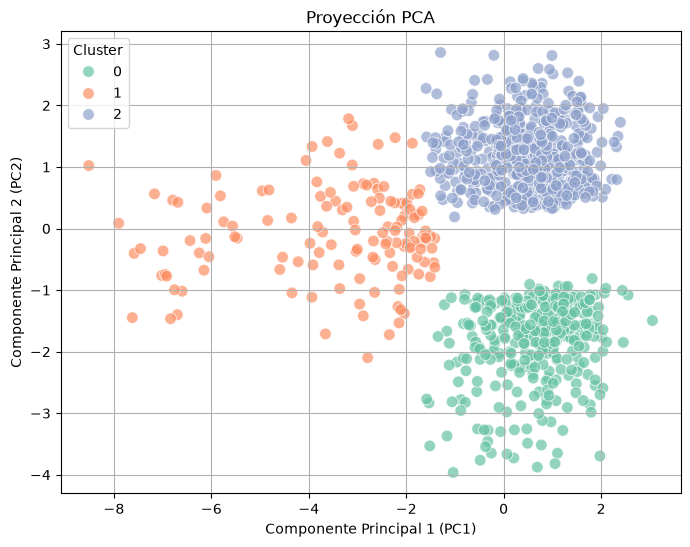

In [ ]:
## aplicar la reducción de dimensionalidad
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_escala)

# Crear los dos componentes principales
arc_escalado = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
arc_escalado['Cluster'] = canciones_limpio['Cluster'].values

# 4. Graficar con scatterplot para visualizar las agrupaciones, colocando colores para diferenciar
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='Cluster',       
    palette='Set2',     
    data=arc_escalado,   
    alpha=0.7, 
    s=70               
)

plt.title('Proyección PCA')
plt.xlabel('Componente Principal 1 (PC1)')
plt.ylabel('Componente Principal 2 (PC2)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

### Bloque 4: Modelado (Usa K-Means o DB Scan para generar los clusters)

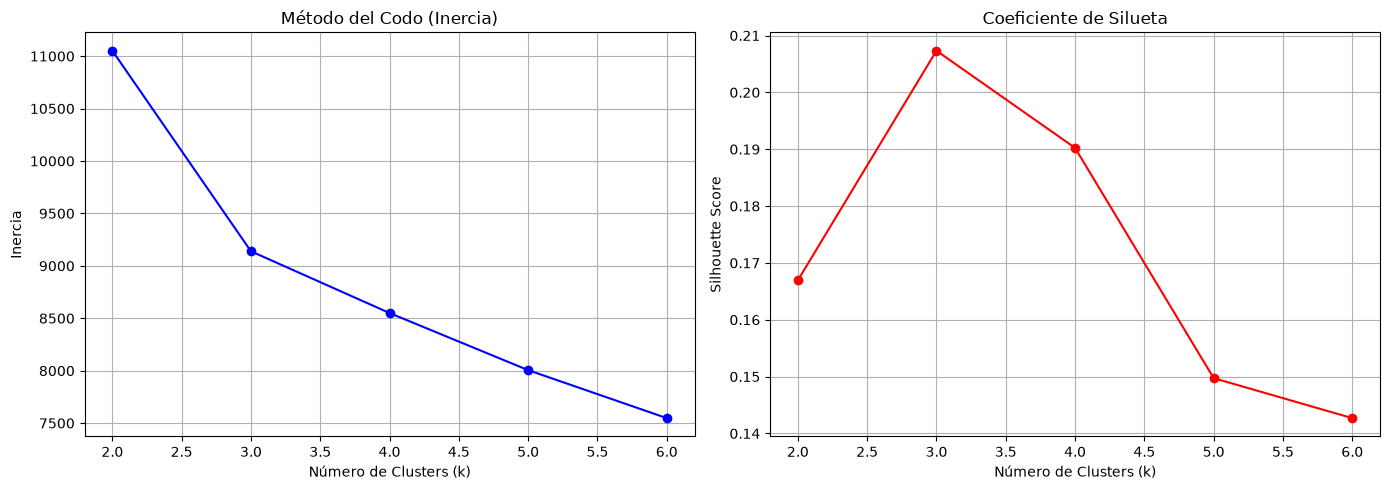

In [ ]:
inercia = []
silhouette_vals = []
K_range = range(2, 7)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_escala) 
    
    inercia.append(kmeans.inertia_)
    silhouette_vals.append(silhouette_score(X_escala, kmeans.labels_))

# Visualización del Método del Codo y Silhouette Score
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica codo
ax[0].plot(K_range, inercia, 'bo-')
ax[0].set_title('Método del Codo (Inercia)')
ax[0].set_xlabel('Número de Clusters (k)')
ax[0].set_ylabel('Inercia')
ax[0].grid(True)

# Gráfica Silueta
ax[1].plot(K_range, silhouette_vals, 'ro-')
ax[1].set_title('Coeficiente de Silueta')
ax[1].set_xlabel('Número de Clusters (k)')
ax[1].set_ylabel('Silhouette Score')
ax[1].grid(True)

plt.tight_layout()
plt.show()


### Bloque 5: Visualización y Análisis
Genera visualizaciones que permitan interpretar qué significa cada grupo.

In [ ]:
## Ayuda a deterrminar la cantidad de agrupaciones que vimos que se crearon en el scatterplot para realizar las graficas
num_grupos = 3
gru_final = KMeans(n_clusters=num_grupos, random_state=42, n_init=10)

canciones_limpio['Cluster'] = gru_final.fit_predict(X_escala)
arc_escalado['Cluster'] = canciones_limpio['Cluster']

# Crear la primera vizualización según promedio y grupos (utilizamos el .T para organizar la info verticalmente)
perfil_clusters = canciones_limpio.groupby('Cluster').mean().T
print("Promedio de variables según agrupación")
display(perfil_clusters)

Promedio de variables por Cluster:


Cluster,0,1,2
track_popularity,65.122873,45.079710,56.330330
danceability,0.708268,0.463000,0.519105
energy,0.661529,0.315523,0.802015
key,5.376181,5.224638,5.039039
loudness,-6.468809,-14.562058,-5.191619
mode,0.512287,0.695652,0.738739
speechiness,0.104112,0.053964,0.086724
acousticness,0.251874,0.727229,0.096820
instrumentalness,0.004979,0.373967,0.061438
liveness,0.145901,0.133055,0.280081


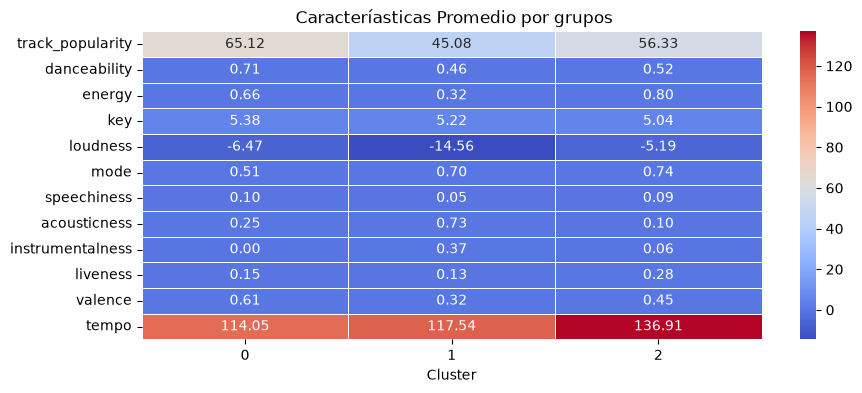

In [31]:
# Crear segunda vizualización con una mapa de calor; para identificar las diferencias entre cada agrupación 
plt.figure(figsize=(10, 4))
sns.heatmap(perfil_clusters, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title(' Caracteríasticas Promedio por grupos')
plt.show()

### Conclusiones

Plantear 3 conclusiones propias basadas en los resultados obtenidos

* **Grupo 0:**
   Es el grupo con la mayor bailabilidad (0.71), conplementandolo de la misma manera con ser el que posee un mayor valance (0.61). Cetrandonos más hacia los generos, podemos deducir que es musica pop, alegre y percibida bailable, ya que tiene altos indices de popularidad y el bajo indice de instrumentalidad.

 * **Grupo 1:**
   Presenta indices altos en acústica (0.73), instrumentalidad (0.31), y tempo (117.54) y bajos indices en vivacidad (0.13) y energía (0.32); con esto podemos concluir que es un genero calmado e instrumental; como la música romántica o relajante.

 * **Grupo 2:**
   Grupo con valores bastante significativos en tempo (136.91), energía (0.80), siendo el segundo en popularidad (56.33), permite asemejarse con géneros rápidos y fuertes como lo son el rock, música de festivales como la electrónica o música para hacer ejercicio o entrenar.   
